# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [31]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [32]:
corpus = """
As a Computer Science student, I have developed a strong interest in
Artificial Intelligence and Machine Learning because they help solve
real-world problems using data. Through my academic coursework,
internships, and personal projects, I gained hands-on experience in
data preprocessing, feature engineering, model training, and
performance evaluation.

While learning deep learning, I explored Recurrent Neural Networks
(RNNs), Long Short-Term Memory (LSTM) networks, and Gated Recurrent
Units (GRUs) for sequence prediction and text generation tasks. I
realized that selecting appropriate hyperparameters and training the
model with quality data plays an important role in achieving good
results.

Working on practical projects has strengthened my understanding of
machine learning concepts and improved my problem-solving skills. I
look forward to learning advanced AI techniques and building
intelligent applications that can solve meaningful real-world
challenges.
"""
print(corpus)


As a Computer Science student, I have developed a strong interest in
Artificial Intelligence and Machine Learning because they help solve
real-world problems using data. Through my academic coursework,
internships, and personal projects, I gained hands-on experience in
data preprocessing, feature engineering, model training, and
performance evaluation.

While learning deep learning, I explored Recurrent Neural Networks
(RNNs), Long Short-Term Memory (LSTM) networks, and Gated Recurrent
Units (GRUs) for sequence prediction and text generation tasks. I
realized that selecting appropriate hyperparameters and training the
model with quality data plays an important role in achieving good
results.

Working on practical projects has strengthened my understanding of
machine learning concepts and improved my problem-solving skills. I
look forward to learning advanced AI techniques and building
intelligent applications that can solve meaningful real-world
challenges.



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [33]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 103
X shape: (118, 11)
y shape: (118,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [34]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=0
)

print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [35]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_history = lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=0
)

print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [36]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_history = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=0
)

print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

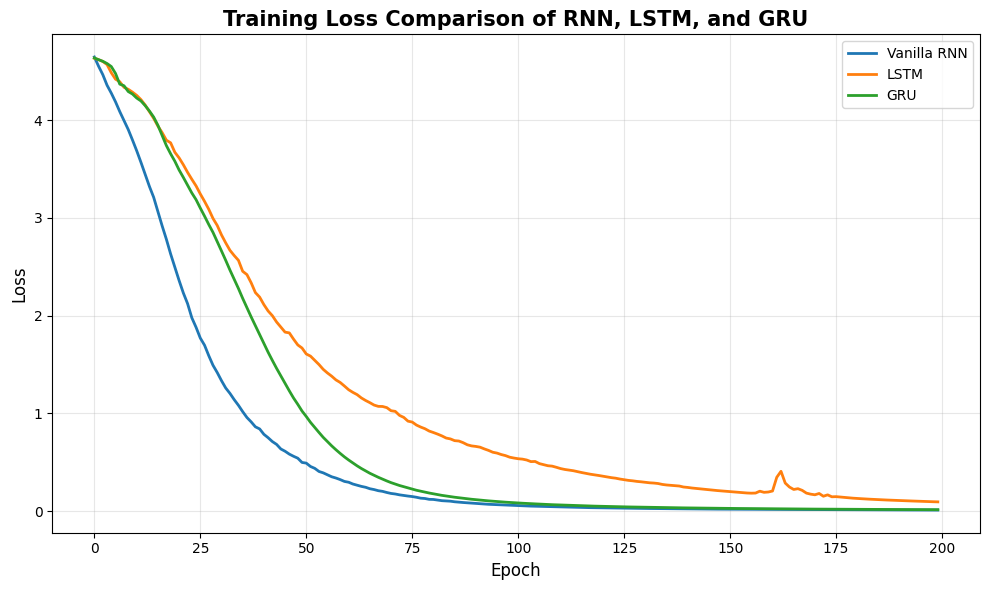

In [37]:
plt.figure(figsize=(10, 6))

plt.plot(rnn_history.history['loss'],
         label='Vanilla RNN',
         linewidth=2)

plt.plot(lstm_history.history['loss'],
         label='LSTM',
         linewidth=2)

plt.plot(gru_history.history['loss'],
         label='GRU',
         linewidth=2)

plt.title("Training Loss Comparison of RNN, LSTM, and GRU",
          fontsize=15,
          fontweight='bold')

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [38]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len - 1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(token_list, verbose=0),
            axis=-1
        )[0]

        output_word = tokenizer.index_word.get(predicted, "")

        seed_text += " " + output_word

    return seed_text

## 🧪 Generate Text Samples

In [39]:
seed_text = "computer science"

print("RNN  :", generate_text(rnn_model, seed_text, 10))
print("LSTM :", generate_text(lstm_model, seed_text, 10))
print("GRU  :", generate_text(gru_model, seed_text, 10))

RNN  : computer science and personal projects developed gained hands on experience in i
LSTM : computer science a computer student i have developed a strong interest in
GRU  : computer science computer science student i have developed a strong interest in


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion

- **Vanilla RNN** learns sequence patterns but struggles with long-term dependencies.
- **LSTM** captures contextual information more effectively for text generation.
- **GRU** provides comparable performance with a simpler architecture and faster training.
- Increasing the **embedding size**, **hidden units**, and **training epochs** improved the overall text generation quality.